# Quantum physics-aware neural networks

A quantum physics-aware neural network (QPANN) predicts how well a noisy quantum
computer will run a given circuit. pyGSTi's implementation lives in
`pygsti.extras.ml`, and it follows the architecture of

> D. Hothem, A. Miller, T. Proctor, *"What is my quantum computer good for? Quantum
> capability learning with physics-aware neural networks"*, NeurIPS 2024.
> [arXiv:2406.05636](https://arxiv.org/abs/2406.05636)

Black-box models for this task throw away everything known about the device and the
circuit. They need a lot of data and they generalize badly to circuits deeper or wider
than the training set. A QPANN splits the prediction into two pieces instead:

1. **A trainable network $N$.** A vectorized, highly localized multi-layer perceptron
   that maps the local gate context of each circuit layer to predicted *rates* for a set
   of local elementary error generators.
2. **A fixed physics layer $f$.** A non-trainable function that propagates those
   layer-wise rates through the Clifford circuit structure to a first-order
   approximation of the circuit's outcome probabilities. The propagation uses Clifford
   tableau arithmetic, so it scales polynomially with qubit count.

Because the physics is baked into the architecture rather than learned, the model
extrapolates to circuits far deeper and wider than it was trained on, learns from small
datasets, and produces weights you can read as physical error rates on physical qubits.

This page walks the whole pipeline: how errors and circuits are represented, how errors
are propagated and localized, and how to build, train, and validate a QPANN against a
simulated device whose true error rates you know.

## Setup

Everything below uses one device: a {{num_qubits}}-qubit line, qubits 0-1-2, with
`Gxpi2` and `Gypi2` everywhere and `Gcphase` on the edges (0,1) and (1,2). A global idle
gate `Gidle` is declared too. It plays no role until the training section, where it
carries the injected noise, and it does not appear in the circuit encoding.

In [1]:
import itertools
import random

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import tensorflow as tf
import keras

import pygsti
from pygsti.circuits import Circuit
from pygsti.processors.processorspec import QubitProcessorSpec as QPS
from pygsti.algorithms.randomcircuit import create_random_circuit
from pygsti.extras.ml import encoding, errgentools as et, snippers, qpanns

print("pyGSTi:", pygsti.__version__, "| TensorFlow:", tf.__version__, "| Keras:", keras.__version__)

num_qubits = 3
qubit_labels = [0, 1, 2]
availability = {'Gcphase': [(0, 1), (1, 2)]}
pspec = QPS(num_qubits=num_qubits, qubit_labels=qubit_labels,
            gate_names=['Gxpi2', 'Gypi2', 'Gcphase', 'Gidle'],
            availability=availability)

# The same 0-1-2 line connectivity, as a standalone graph.
qubit_graph = nx.Graph()
qubit_graph.add_nodes_from(qubit_labels)
qubit_graph.add_edges_from(availability['Gcphase'])

encoder = encoding.StandardCircuitEncoder(pspec)
print("Encoder length:", encoder.length)

I0000 00:00:1787872855.262173    4940 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787872855.339924    4940 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787872858.614052    4940 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


pyGSTi: 0.0.post1.dev1+gbb839b2a9.stage.docs.CLEAN | TensorFlow: 2.21.0 | Keras: 3.15.1
Encoder length: 8


## Pauli and error generator bookkeeping

Noise is represented with the elementary-error-generator formalism of the *Taxonomy of
Small Errors* (Blume-Kohout et al.). Two of the four sectors carry most of the weight in
practice:

* **Hamiltonian (coherent) errors, `'H'`**, indexed by a single Pauli string. `H_XI` is
  a coherent X-rotation-like error on qubit 0.
* **Stochastic (incoherent) errors, `'S'`**, also indexed by a single Pauli string.
  `S_IX` is a stochastic Pauli-X flip on qubit 1.

`pygsti.extras.ml.errgentools` converts Pauli strings to integer indices and back. That
integer indexing is the global bookkeeping everything else is built on.

In [2]:
# Map a Pauli string to its base-4 integer index. Leftmost character is qubit 0.
n = 2
ps_idx = et.paulistring_to_index('IX', n)
print(f"Pauli string 'IX' maps to integer index: {ps_idx}")
print(f"Index {ps_idx} maps back to Pauli string: {et.index_to_paulistring(ps_idx, n)!r}")

# Global index of a modelled error generator.
# 'H' occupies [0, 4**n); 'S' occupies [4**n, 2*4**n).
h_idx = et.error_generator_index('H', ('IX',))
s_idx = et.error_generator_index('S', ('IX',))
print(f"Index of H_IX: {h_idx}")
print(f"Index of S_IX: {s_idx}")

print(f"Index {s_idx} represents error generator: {et.index_to_error_gen(s_idx, n)}")
print(f"Total possible H+S error generators for {n} qubits: {2 * (4**n)}")

Pauli string 'IX' maps to integer index: 1
Index 1 maps back to Pauli string: 'IX'
Index of H_IX: 1
Index of S_IX: 17
Index 17 represents error generator: ('S', ('IX',))
Total possible H+S error generators for 2 qubits: 32


## Enumerating local, low-weight error generators

The number of possible error generators on $n$ qubits grows like $4^n$. To keep the
network polynomial in size, you let it predict rates only for a plausible subset $G$:
all weight-1 generators, plus weight-2 generators supported on connected edges of the
device's qubit graph.

`up_to_weight_k_error_gens_from_qubit_graph` does that enumeration. It (and
`layer_snipper_from_qubit_graph`, below) accepts a `networkx` graph, an
`igraph`/`graph-tool` graph, pyGSTi's own `QubitGraph` or `QubitProcessorSpec`, or a raw
adjacency matrix. See `pygsti.extras.ml.graphtools` for the full list. Here is the line
graph with a hop distance of {{num_hops}}.

In [3]:
modelled_error_generators = et.up_to_weight_k_error_gens_from_qubit_graph(
    k=2, n=num_qubits, qubit_graph=qubit_graph, num_hops=1, egtypes=['H', 'S']
)

print(f"Total local error generators enumerated (k=2, hops=1): {len(modelled_error_generators)}")
print("Sample generators:")
random.seed(0)
for eg in random.sample(modelled_error_generators, 10):
    print(" ", eg)

# `pspec` itself, or a raw adjacency matrix, would work identically here.
same = et.up_to_weight_k_error_gens_from_qubit_graph(
    k=2, n=num_qubits, qubit_graph=np.array([[0, 1, 0], [1, 0, 1], [0, 1, 0]]),
    num_hops=1, egtypes=['H', 'S']
)
print("Adjacency-matrix form gives the same set:", set(same) == set(modelled_error_generators))

Total local error generators enumerated (k=2, hops=1): 54
Sample generators:
  ('H', ('IZX',))
  ('S', ('IYX',))
  ('H', ('IZZ',))
  ('H', ('ZII',))
  ('H', ('ZYI',))
  ('S', ('IZI',))
  ('S', ('IYI',))
  ('H', ('IZY',))
  ('H', ('IXY',))
  ('S', ('IXI',))
Adjacency-matrix form gives the same set: True


## Pauli-correlation and active error generators

The paper demonstrates H and S errors, but the code supports all four sectors of the
taxonomy:

* **Pauli-correlation errors, `'C'`**, symmetric, indexed by an unordered pair of
  distinct non-identity Paulis. These are correlated stochastic noise.
* **Active errors, `'A'`**, antisymmetric, indexed by an unordered pair of distinct
  non-identity Paulis. These are coherent, amplitude-damping-like, non-unital crosstalk.

Active generators are antisymmetric under swapping the pair ($A_{P,Q} = -A_{Q,P}$), so
`errgentools` canonicalizes pairs lexicographically and reports the sign that swap
costs. That sign is $-1$ only for an `'A'` generator whose pair had to be swapped.

In [4]:
P, Q, was_swapped = et.canonical_pauli_pair('ZZ', 'XY')
print(f"Canonical pair: ({P!r}, {Q!r}), swapped={was_swapped}")

print("C canonicalization sign (swapped):", et.error_generator_canonicalization_sign('C', ('ZZ', 'XY')))
print("A canonicalization sign (swapped):", et.error_generator_canonicalization_sign('A', ('ZZ', 'XY')))
print("A canonicalization sign (no-swap):", et.error_generator_canonicalization_sign('A', ('XY', 'ZZ')))

modelled_all_four = et.up_to_weight_k_error_gens_from_qubit_graph(
    k=2, n=num_qubits, qubit_graph=qubit_graph, num_hops=1, egtypes=['H', 'S', 'C', 'A']
)
print(f"Total error generators including C/A (k=2, hops=1): {len(modelled_all_four)}")

Canonical pair: ('XY', 'ZZ'), swapped=True
C canonicalization sign (swapped): 1
A canonicalization sign (swapped): -1
A canonicalization sign (no-swap): 1
Total error generators including C/A (k=2, hops=1): 468


## Encoding circuits as tensors

Each circuit layer becomes a numeric vector. `StandardCircuitEncoder` maps a layer to a
multi-hot binary vector of length `encoder.length`, which is the number of available
gate placements (gate name plus qubits) on the processor. A layer containing gates
$g_1, g_2, \dots$ has $1.0$ at their indices and $0.0$ elsewhere. Note that the global
idle is not one of these placements, so declaring `Gidle` on the `ProcessorSpec` above
left `encoder.length` unchanged.

`circuits_to_tensor` batches encoded circuits into a padded 3D array of shape
`(num_circuits, max_depth, encoder.length)`.

In [5]:
demo_circuits = [
    Circuit('[Gxpi2:0Gypi2:1]@(0,1,2)'),                     # depth 1
    Circuit('[Gcphase:0:1Gypi2:2][Gxpi2:1Gypi2:0]@(0,1,2)')  # depth 2
]

print(f"Encoder gate indexing (length {encoder.length}):")
for idx, gate in enumerate(encoder.gate_indexing):
    print(f"  Index {idx} -> {gate}")

print(f"\nDefined {len(demo_circuits)} test circuits:")
for idx, circuit in enumerate(demo_circuits):
    print(f"  Circuit {idx}:")
    print(circuit)

demo_tensor = encoding.circuits_to_tensor(demo_circuits, encoder)
print(f"\nCircuits tensor shape: {demo_tensor.shape} (num_circuits, max_depth, encoder.length)")
print("Circuit 0 encoded (depth 1, zero-padded at layer 1):\n", demo_tensor[0])
print("Circuit 1 encoded (depth 2):\n", demo_tensor[1])

Encoder gate indexing (length 8):
  Index 0 -> Gxpi2:0
  Index 1 -> Gxpi2:1
  Index 2 -> Gxpi2:2
  Index 3 -> Gypi2:0
  Index 4 -> Gypi2:1
  Index 5 -> Gypi2:2
  Index 6 -> Gcphase:0:1
  Index 7 -> Gcphase:1:2

Defined 2 test circuits:
  Circuit 0:
Qubit 0 ---|Gxpi2|---
Qubit 1 ---|Gypi2|---
Qubit 2 ---|     |---

  Circuit 1:
Qubit 0 ---| C1  |-|Gypi2|---
Qubit 1 ---| C0  |-|Gxpi2|---
Qubit 2 ---|Gypi2|-|     |---


Circuits tensor shape: (2, 2, 8) (num_circuits, max_depth, encoder.length)
Circuit 0 encoded (depth 1, zero-padded at layer 1):
 [[1. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]
Circuit 1 encoded (depth 2):
 [[0. 0. 0. 0. 0. 1. 1. 0.]
 [0. 1. 0. 1. 0. 0. 0. 0.]]


## Clifford error propagation

Here is the trick the whole architecture rests on. For Clifford-only circuits, an
elementary error generator $G_j$ inserted after layer $l$ can be pushed forward through
every subsequent layer to the end of the circuit, because conjugation by a Clifford maps
a Pauli to another Pauli, up to a sign. So $G_j$ at layer $l$ lands on some canonical
end-of-circuit generator $G_k$ with a sign $\pm 1$:

$$G_j \xrightarrow{\text{Clifford}} s \cdot G_k$$

`circuit_error_propagation_matrices` computes that mapping for one circuit and returns
`indices` (the canonical global index each error propagates to) and `signs` (the $\pm 1$
picked up along the way).

In [6]:
prop_circuit = Circuit('[Gxpi2:0][Gcphase:0:1]@(0,1,2)')
print(prop_circuit)

error_generators = [('H', ('XII',)), ('S', ('IXI',)), ('S', ('ZII',))]

indices, signs = encoding.circuit_error_propagation_matrices(prop_circuit, error_generators)
print("Indices matrix (depth x num_generators):\n", indices)
print("Signs matrix (depth x num_generators):\n", signs)

print("\nWhere each generator lands, per insertion layer:")
for layer in range(indices.shape[0]):
    for j, eg in enumerate(error_generators):
        landed = et.index_to_error_gen(int(indices[layer, j]), num_qubits)
        print(f"  layer {layer}: {eg} -> {landed}, sign {int(signs[layer, j]):+d}")

Qubit 0 ---|Gxpi2|-|C1|---
Qubit 1 ---|     |-|C0|---
Qubit 2 ---|     |-|  |---

Indices matrix (depth x num_generators):
 [[ 28 116 112]
 [ 16  68 112]]
Signs matrix (depth x num_generators):
 [[1. 1. 1.]
 [1. 1. 1.]]

Where each generator lands, per insertion layer:
  layer 0: ('H', ('XII',)) -> ('H', ('XZI',)), sign +1
  layer 0: ('S', ('IXI',)) -> ('S', ('ZXI',)), sign +1
  layer 0: ('S', ('ZII',)) -> ('S', ('ZII',)), sign +1
  layer 1: ('H', ('XII',)) -> ('H', ('XII',)), sign +1
  layer 1: ('S', ('IXI',)) -> ('S', ('IXI',)), sign +1
  layer 1: ('S', ('ZII',)) -> ('S', ('ZII',)), sign +1


Read the last row first. An error inserted after the final layer has nothing left to
propagate through, so it maps to its own index with sign $+1$. The first row is the
interesting one: those errors must cross `Gcphase:0:1`. `Gcphase` is diagonal, so a $Z$
error on qubit 0 commutes with it and is unchanged. A coherent $X$ error on qubit 0
becomes a joint $XZ$ error on qubits 0 and 1, and a stochastic $X$ on qubit 1 picks up a
$Z$ on qubit 0 the same way.

## First-order sensitivities

The first-order sensitivity of a bitstring outcome probability $P(x)$ to an
end-of-circuit generator $G_k$ is a coefficient $\alpha(G_k, x)$, derived in
[Efficient simulation of Clifford circuits with small Markovian errors](https://arxiv.org/abs/2504.15128).

The batched entry point is `error_generator_tensors`. With
`alpha_representation='concise'` (the default, and the more scalable mode) it returns
`probabilities`, the noise-free ideal outcome probabilities of each circuit, and
`alphas`, a 4D tensor of shape
`(num_circuits, 2**n, max_depth, num_error_generators)`.

In [7]:
alpha_circuits = [
    Circuit('[Gxpi2:0Gypi2:1]@(0,1,2)'),
    Circuit('[Gxpi2:0][Gcphase:0:1]@(0,1,2)')
]

tensors = encoding.error_generator_tensors(alpha_circuits, error_generators, pspec,
                                           alpha_representation='concise')

print("tensors.keys():", list(tensors.keys()))
print("Ideal probabilities shape:", tensors['probabilities'].shape, " (num_circuits, 2**n)")
print("Alphas shape:", tensors['alphas'].shape, " (num_circuits, 2**n, max_depth, num_error_generators)")
print("\nCircuit 1 ideal bitstring probabilities:\n", tensors['probabilities'][1])

100%|██████████| 2/2 [00:00<00:00, 0.00it/s]

tensors.keys(): ['indices', 'signs', 'probabilities', 'alphas']
Ideal probabilities shape: (2, 8)  (num_circuits, 2**n)
Alphas shape: (2, 8, 2, 3)  (num_circuits, 2**n, max_depth, num_error_generators)

Circuit 1 ideal bitstring probabilities:
 [0.5 0.  0.  0.  0.5 0.  0.  0. ]


## Locality filters: the snipper

On real hardware, an error on some set of qubits is usually caused by gates acting on
those qubits or their near neighbors. A QPANN encodes that assumption with a **snipper**:
a list of index lists, one per candidate error generator, naming the columns of the
circuit-encoding tensor that generator's sub-network is allowed to see. Restricting the
inputs this way cuts the parameter count hard and keeps the model from overfitting.

`layer_snipper_from_qubit_graph` builds one. `hops=0` means the sub-network for a
generator supported on qubit $q$ sees only gates acting on $q$; `hops=1` adds gates on
$q$'s graph neighbors.

In [8]:
snipper_hops0 = snippers.layer_snipper_from_qubit_graph(error_generators, encoder, qubit_graph, hops=0)
snipper_hops1 = snippers.layer_snipper_from_qubit_graph(error_generators, encoder, qubit_graph, hops=1)

for j, eg in enumerate(error_generators):
    print(f"Gen {j} -> {eg}")
    print(f"  hops=0: {snipper_hops0[j]} (gates: {[encoder.gate_indexing[i] for i in snipper_hops0[j]]})")
    print(f"  hops=1: {snipper_hops1[j]} (gates: {[encoder.gate_indexing[i] for i in snipper_hops1[j]]})")

Gen 0 -> ('H', ('XII',))
  hops=0: [0, 3, 6] (gates: [Label(('Gxpi2', 0)), Label(('Gypi2', 0)), Label(('Gcphase', 0, 1))])
  hops=1: [0, 1, 3, 4, 6, 7] (gates: [Label(('Gxpi2', 0)), Label(('Gxpi2', 1)), Label(('Gypi2', 0)), Label(('Gypi2', 1)), Label(('Gcphase', 0, 1)), Label(('Gcphase', 1, 2))])
Gen 1 -> ('S', ('IXI',))
  hops=0: [1, 4, 6, 7] (gates: [Label(('Gxpi2', 1)), Label(('Gypi2', 1)), Label(('Gcphase', 0, 1)), Label(('Gcphase', 1, 2))])
  hops=1: [0, 1, 2, 3, 4, 5, 6, 7] (gates: [Label(('Gxpi2', 0)), Label(('Gxpi2', 1)), Label(('Gxpi2', 2)), Label(('Gypi2', 0)), Label(('Gypi2', 1)), Label(('Gypi2', 2)), Label(('Gcphase', 0, 1)), Label(('Gcphase', 1, 2))])
Gen 2 -> ('S', ('ZII',))
  hops=0: [0, 3, 6] (gates: [Label(('Gxpi2', 0)), Label(('Gypi2', 0)), Label(('Gcphase', 0, 1))])
  hops=1: [0, 1, 3, 4, 6, 7] (gates: [Label(('Gxpi2', 0)), Label(('Gxpi2', 1)), Label(('Gypi2', 0)), Label(('Gypi2', 1)), Label(('Gcphase', 0, 1)), Label(('Gcphase', 1, 2))])


Passing `pspec` in place of `qubit_graph` gives the same answer here, since its
`Gcphase` availability already declares the 0-1-2 line. A raw adjacency matrix, built by
hand or with `snippers.undirected_adjacency_matrix_from_edges`, works too.

## The QPANN model

`qpanns.QPANN` subclasses `keras.Model`. It takes a list of three tensors,

```
x = [circuits_tensor, alphas, probabilities_ideal]
```

matching the `'concise'` probability mode. Build one over all four error sectors and run
an untrained forward pass. The model's `stochastic_mask` marks the design point worth
knowing: only `'S'` generators are squared, to force their rates non-negative. H, C, and
A fall through to the same unconstrained linear branch.

In [9]:
# Pair ('IXI', 'XII') is already lexicographically sorted, which matters later.
demo_error_generators = [
    ('H', ('XII',)), ('S', ('IXI',)),
    ('C', ('IXI', 'XII')), ('A', ('IXI', 'XII'))
]

demo_tensors = encoding.error_generator_tensors(demo_circuits, demo_error_generators, pspec,
                                                alpha_representation='concise')
demo_probs_ideal, demo_alphas = demo_tensors['probabilities'], demo_tensors['alphas']

demo_snipper = snippers.layer_snipper_from_qubit_graph(
    demo_error_generators, encoder, qubit_graph, hops=1)
demo_qpann = qpanns.QPANN(encoder.length, demo_error_generators, demo_snipper)

output = demo_qpann([demo_tensor, demo_alphas, demo_probs_ideal])
print("Untrained model output shape:", output.shape, " (num_circuits, 2**n)")
print("Untrained predictions for circuit 0:\n", output[0].numpy())
print("Ideal noise-free probabilities for circuit 0:\n", demo_probs_ideal[0])

print("\nstochastic_mask:", demo_qpann.stochastic_mask)
print("Columns that get squared:",
      [eg[0] for eg, is_s in zip(demo_qpann.modelled_error_generators, demo_qpann.stochastic_mask) if is_s])

100%|██████████| 2/2 [00:00<00:00, 0.00it/s]
E0000 00:00:1787872866.936803    4940 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Untrained model output shape: (2, 8)  (num_circuits, 2**n)
Untrained predictions for circuit 0:
 [0.25004414 0.         0.25004414 0.         0.24995585 0.
 0.24995585 0.        ]
Ideal noise-free probabilities for circuit 0:
 [0.25 0.   0.25 0.   0.25 0.   0.25 0.  ]

stochastic_mask: [False  True False False]
Columns that get squared: ['S']


## Generating synthetic ground-truth data

To show that training recovers physics, you need a dataset whose true underlying rates
you already know. Build one with pyGSTi's cloud crosstalk model:

1. Attach a dictionary of known error rates to the global idle gate `Gidle`.
2. Build a `CloudNoiseModel` with `implicit_idle_mode='add_global'`, which composes that
   same noisy idle onto *every* circuit layer. That is a constant-rate-per-layer noise
   model.
3. Sample {{num_circuits}} random circuits, simulate their exact (not linearized)
   outcome probabilities, and use those as the training targets $y$.

Three things will bite you here.

**The CP bound.** For a completely positive channel the stochastic and correlation
coefficients have to satisfy positive-semidefiniteness. Non-zero C or A rates on a pair
$(P, Q)$ require large enough S rates on $P$ and on $Q$ individually:

$$c^2 + a^2 \le s_P \cdot s_Q$$

Violate it, or leave the S rates out, and pyGSTi's model builder raises
`Lindblad coefficients are not CPTP!`.

**Lexicographic sorting is mandatory.** The model builder expects C and A Pauli pairs
sorted (`'IYI' < 'XII'`). A reversed key like `('A', 'XII', 'IYI')` is dropped silently,
with no warning and no error, and contributes exactly $0.0$ to the simulation. Sort the
pairs, then read the coefficients back and check.

**Active sign consistency.** Since $A_{P,Q} = -A_{Q,P}$, writing every pair in sorted
order in both the model key and the QPANN's generator list means injected and learned
rates compare directly, with no hidden sign flip.

In [10]:
RNG_SEED = 12345

# 1. C/A pairs in sorted order. Pair 1 is supported on {0,1}, pair 2 on {1,2}.
P1, Q1 = sorted(['XII', 'IYI'])
P2, Q2 = sorted(['IYI', 'IIX'])
assert (P1, Q1) == ('IYI', 'XII') and (P2, Q2) == ('IIX', 'IYI'), "Sort your C/A pairs!"

true_error_generators = [
    ('H', ('XII',)),   # coherent X on qubit 0
    ('H', ('IYI',)),   # coherent Y on qubit 1
    ('S', ('XII',)),   # stochastic X on qubit 0
    ('S', ('IYI',)),   # stochastic Y on qubit 1
    ('S', ('IIX',)),   # stochastic X on qubit 2
    ('C', (P1, Q1)),   # Pauli-correlation on qubits {0,1}
    ('A', (P1, Q1)),   # active error on qubits {0,1}
    ('C', (P2, Q2)),   # Pauli-correlation on qubits {1,2}
    ('A', (P2, Q2)),   # active error on qubits {1,2}
]
s_XII, s_IYI, s_IIX = 0.005, 0.004, 0.003
c1, a1 = 0.0020, 0.0018
c2, a2 = 0.0012, 0.0010
true_rates = np.array([0.006, 0.004, s_XII, s_IYI, s_IIX, c1, a1, c2, a2])

assert c1**2 + a1**2 <= s_IYI * s_XII, "C1/A1 rates violate the CP bound!"
assert c2**2 + a2**2 <= s_IYI * s_IIX, "C2/A2 rates violate the CP bound!"
print(f"CP check (pair 1): sqrt(c^2 + a^2) = {np.hypot(c1, a1):.6f} <= sqrt(s_P s_Q) = {np.sqrt(s_IYI*s_XII):.6f}")
print(f"CP check (pair 2): sqrt(c^2 + a^2) = {np.hypot(c2, a2):.6f} <= sqrt(s_P s_Q) = {np.sqrt(s_IYI*s_IIX):.6f}")

CP check (pair 1): sqrt(c^2 + a^2) = 0.002691 <= sqrt(s_P s_Q) = 0.004472
CP check (pair 2): sqrt(c^2 + a^2) = 0.001562 <= sqrt(s_P s_Q) = 0.003464


In [11]:
# 2. Build the exact noisy simulator. Lindblad coefficient keys are flat tuples.
def ml_gen_to_lindblad_key(eg):
    typ, bels = eg
    return (typ,) + tuple(bels)

lindblad_error_coeffs = {
    'Gidle': {ml_gen_to_lindblad_key(eg): float(r)
              for eg, r in zip(true_error_generators, true_rates)}
}
error_model = pygsti.models.create_cloud_crosstalk_model(
    pspec, lindblad_error_coeffs=lindblad_error_coeffs,
    errcomp_type="errorgens", implicit_idle_mode='add_global'
)

# Read the realized coefficients back to confirm nothing was silently dropped.
realized = error_model.operation_blks['cloudnoise'][pygsti.baseobjs.Label('Gidle')].coefficients()
print("Realized coefficients on Gidle:")
for k, v in sorted(realized.items(), key=lambda kv: str(kv[0])):
    if abs(v) > 1e-12:
        print(f"   {str(k):<22s} = {v:+.6f}")
assert len([v for v in realized.values() if abs(v) > 1e-12]) == len(true_error_generators), \
    "A key was silently dropped!"

Realized coefficients on Gidle:
   A(IX,YI:1,2)           = +0.001000
   A(IY,XI:0,1)           = +0.001800
   C(IX,YI:1,2)           = +0.001200
   C(IY,XI:0,1)           = +0.002000
   H(X:0)                 = +0.006000
   H(Y:1)                 = +0.004000
   S(X:0)                 = +0.005000
   S(X:2)                 = +0.003000
   S(Y:1)                 = +0.004000


In [12]:
# 3. Sample random circuits and simulate exact outcome probabilities.
rand_state = np.random.RandomState(RNG_SEED)
num_circuits = 60
circuits = [
    create_random_circuit(pspec, int(rand_state.randint(5, 13)), sampler='edgegrab',
                          samplerargs=[0.5], rand_state=rand_state)
    for _ in range(num_circuits)
]

nbit_strings = [''.join(p) for p in itertools.product('01', repeat=num_qubits)]
exact_probabilities = np.zeros((num_circuits, 2**num_qubits))
for i, circuit in enumerate(circuits):
    probs_dict = error_model.probabilities(circuit)
    exact_probabilities[i, :] = [probs_dict[(bs,)] for bs in nbit_strings]

# 4. Compute the QPANN inputs.
train_tensors = encoding.error_generator_tensors(
    circuits, true_error_generators, pspec, alpha_representation='concise'
)
probabilities_ideal = train_tensors['probabilities']
alphas = train_tensors['alphas']

# 5. Check how good the first-order approximation actually is.
approx_probabilities = probabilities_ideal + np.einsum('nbdg,g->nb', alphas, true_rates)
abs_diff = np.abs(exact_probabilities - approx_probabilities)
true_deviation = np.abs(exact_probabilities - probabilities_ideal)
print(f"Max exact-vs-first-order discrepancy over {num_circuits} circuits: {abs_diff.max():.6f}")
print(f"Mean exact-vs-first-order discrepancy: {abs_diff.mean():.6f}")
print(f"Mean noise-induced probability shift (the signal): {true_deviation.mean():.6f}")
print(f"Unexplained signal fraction: {abs_diff.mean() / true_deviation.mean():.2%}")

100%|██████████| 60/60 [00:00<00:00, 0.00it/s]


Max exact-vs-first-order discrepancy over 60 circuits: 0.004106
Mean exact-vs-first-order discrepancy: 0.000573
Mean noise-induced probability shift (the signal): 0.009224
Unexplained signal fraction: 6.21%


## Training

Two-Pauli C and A generators add degrees of freedom the network has to disentangle, so
this needs more data and more epochs than an H/S-only fit. Train on {{num_circuits}}
circuits for up to {{epochs}} epochs at a learning rate of {{learning_rate}}, with
`EarlyStopping` on **`val_loss`** and a patience of 80.

Watch `val_loss` rather than R², and here is why. Validation R² reaches four nines within
about twenty epochs and stays there for the couple of hundred epochs that follow, while
the loss keeps falling by orders of magnitude. R² will tell you the fit is done long
before the rates have converged.

```{note}
`num_circuits`, `epochs` and `batch_size` are sized so this page builds quickly in CI.
They are not tuned limits, and you should feel free to raise them.

Be aware of what raising them does and does not buy you on *this* example. The
`EarlyStopping` callback halts on `val_loss` well short of the `epochs` cap, and raising
the dataset to 200 circuits lands the nine rates in the same band you will see here. On a
problem this small, more data and more epochs are not the binding constraint.

Where you will need to scale up is on harder problems: more qubits, a larger set of
modelled error generators, higher-depth circuits, or real experimental data with
finite-sample shot noise instead of exact simulated probabilities. In those regimes raise
`num_circuits` first, since the number of independent constraints on the rates is usually
what limits accuracy, then raise `epochs` and the `EarlyStopping` `patience` together so
the optimizer is actually allowed to use them.
```

Training QPANN (H+S+C+A)...
Training finished after 226 epochs.
Final validation R2 score: 0.99998


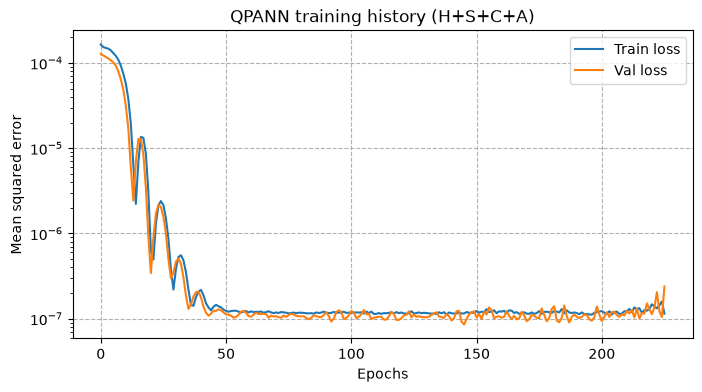

In [13]:
circuits_tensor = encoding.circuits_to_tensor(circuits, encoder)

# `pspec` declares 'Gcphase' on the 0-1-2 line, so it can serve as the qubit graph directly.
snipper = snippers.layer_snipper_from_qubit_graph(true_error_generators, encoder, pspec, hops=1)

model = qpanns.QPANN(encoder.length, true_error_generators, snipper)
x = [circuits_tensor, alphas, probabilities_ideal]

epochs = 400
learning_rate = 2e-3
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='mse', metrics=['R2Score', 'mae'])
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=80,
                                                  restore_best_weights=True)

print("Training QPANN (H+S+C+A)...")
history = model.fit(x, exact_probabilities, epochs=epochs, batch_size=32,
                    callbacks=[early_stopping], validation_split=0.2, verbose=0)
print(f"Training finished after {len(history.history['loss'])} epochs.")
print(f"Final validation R2 score: {history.history['val_R2Score'][-1]:.5f}")

plt.figure(figsize=(8, 4))
plt.semilogy(history.history['loss'], label='Train loss')
plt.semilogy(history.history['val_loss'], label='Val loss')
plt.title('QPANN training history (H+S+C+A)')
plt.xlabel('Epochs')
plt.ylabel('Mean squared error')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

## Extracting and validating the learned rates

The synthetic device has a constant rate per layer, so the QPANN's predicted rates should
come out nearly constant across layers and close to the injected values. Pull them out by
calling the model's dense rate-prediction layer on a dummy layer encoding, then compare.

The last check is worth its own line: the network's output layer does not enforce the CP
bound architecturally, so whether the *learned* C/A rates satisfy $c^2 + a^2 \le s_P s_Q$
is a real test, not a tautology.

In [14]:
test_inputs = tf.zeros((1, encoder.length), dtype=tf.float32)
learned_rates = tf.squeeze(model.dense_layer(test_inputs)).numpy()

print(f"{'Error generator':<26s} | {'True rate':>10s} | {'Learned rate':>12s} | {'Abs error':>10s} | {'Rel error':>9s}")
print("-" * 78)
for eg, t_rate, l_rate in zip(true_error_generators, true_rates, learned_rates):
    abs_err = abs(t_rate - l_rate)
    lbl = f"{eg[0]}({','.join(eg[1])})"
    print(f"{lbl:<26s} | {t_rate:>10.5f} | {l_rate:>12.5f} | {abs_err:>10.5f} | {abs_err/abs(t_rate):>8.1%}")

l_s_XII, l_s_IYI, l_s_IIX = learned_rates[2], learned_rates[3], learned_rates[4]
l_c1, l_a1 = learned_rates[5], learned_rates[6]
l_c2, l_a2 = learned_rates[7], learned_rates[8]

for name, lc, la, lsp, lsq in [("pair 1 (qubits 0,1)", l_c1, l_a1, l_s_IYI, l_s_XII),
                               ("pair 2 (qubits 1,2)", l_c2, l_a2, l_s_IYI, l_s_IIX)]:
    lhs, rhs = np.hypot(lc, la), np.sqrt(abs(lsp * lsq))
    print(f"\nLearned CP check, {name}: sqrt(c^2 + a^2) = {lhs:.6f} vs sqrt(s_P s_Q) = {rhs:.6f}")
    print("  -> satisfied." if lc**2 + la**2 <= lsp * lsq
          else "  -> violated (the network does not enforce this).")

Error generator            |  True rate | Learned rate |  Abs error | Rel error
------------------------------------------------------------------------------
H(XII)                     |    0.00600 |      0.00560 |    0.00040 |     6.6%
H(IYI)                     |    0.00400 |      0.00363 |    0.00037 |     9.2%
S(XII)                     |    0.00500 |      0.00472 |    0.00028 |     5.7%
S(IYI)                     |    0.00400 |      0.00384 |    0.00016 |     4.1%
S(IIX)                     |    0.00300 |      0.00279 |    0.00021 |     7.1%
C(IYI,XII)                 |    0.00200 |      0.00182 |    0.00018 |     9.2%
A(IYI,XII)                 |    0.00180 |      0.00168 |    0.00012 |     6.8%
C(IIX,IYI)                 |    0.00120 |      0.00109 |    0.00011 |     9.5%
A(IIX,IYI)                 |    0.00100 |      0.00099 |    0.00001 |     1.2%

Learned CP check, pair 1 (qubits 0,1): sqrt(c^2 + a^2) = 0.002472 vs sqrt(s_P s_Q) = 0.004254
  -> satisfied.

Learned CP check, 

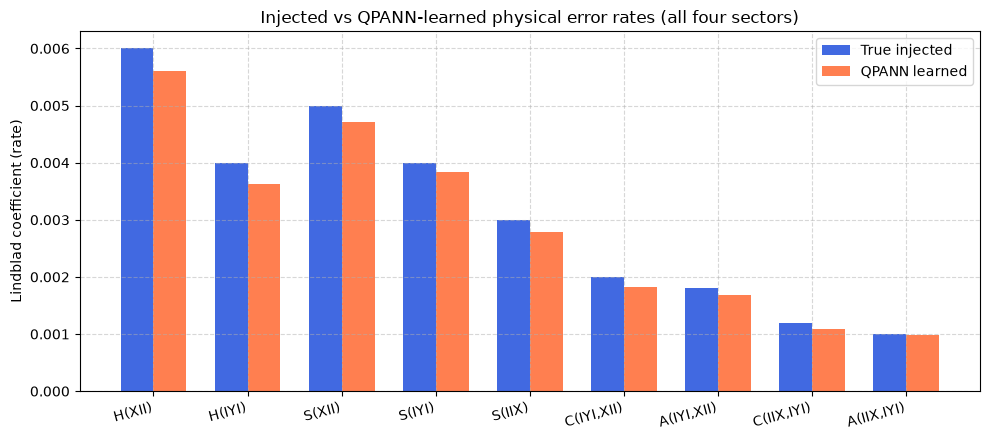

In [15]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x_indices = np.arange(len(true_error_generators))
bar_width = 0.35

ax.bar(x_indices - bar_width/2, true_rates, bar_width, label='True injected', color='royalblue')
ax.bar(x_indices + bar_width/2, learned_rates, bar_width, label='QPANN learned', color='coral')

ax.set_title('Injected vs QPANN-learned physical error rates (all four sectors)')
ax.set_xticks(x_indices)
ax.set_xticklabels([f"{eg[0]}({','.join(eg[1])})" for eg in true_error_generators],
                   rotation=15, ha='right')
ax.set_ylabel('Lindblad coefficient (rate)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

The network saw circuits and outcome probabilities, nothing else. What came back out are
Lindblad coefficients on named qubits: single-qubit coherent and stochastic errors, plus
two-qubit correlated and active crosstalk.

## Limitations

A QPANN is a first-order model. When physical error rates get large, second- and
higher-order BCH terms show up and the linear approximation degrades. There is no
built-in warning when you cross that line, so check the exact-vs-first-order discrepancy
on simulated data before trusting a fit on real data at comparable rates.

The output layer is unconstrained apart from the squaring of S rates. The simulator
enforces $c^2 + a^2 \le s_P s_Q$ when generating data; the network does not enforce it
when predicting. Learned rates can come back unphysical, and you have to check.

Rate recovery on the example above is good to roughly 5-15% relative error, depending on
the rate and on the run: the weights are not seeded, so the numbers you get will differ
from the ones printed here. Across repeated runs the worst-recovered rate has landed
anywhere from about 10% to about 17% off. That is with exact simulated probabilities and
no shot noise; finite sampling makes it worse.

More useful than the size of the error is its sign. **The learned rates come back biased
low, essentially every time** -- across repeated runs of this example, every one of the
nine rates underestimated the injected value, with no exceptions. Treat a QPANN rate as a
lower bound on the error it is estimating rather than an unbiased point estimate, and do
not read a rate that comes back smaller than you expected as good news.

## Further reading

The [NeurIPS 2024 paper](https://arxiv.org/abs/2406.05636) has the benchmarks and the
larger qubit-count simulations. The alpha-coefficient derivation is in
[Efficient simulation of Clifford circuits with small Markovian errors](https://arxiv.org/abs/2504.15128).